# 08 — Final Model Analysis (V2)

This notebook performs the final quantitative and error analysis for the **4-class EfficientNetV2-B0** eye disease classifier.

**Final classes**
- Normal
- Cataract
- Diabetic Retinopathy
- Glaucoma

**Important:** This notebook uses the V2 model and untouched V2 test split only. It does not use the older 5-class model or older test split.


In [17]:
# Step 1 — Configuration and imports
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    auc,
)

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()

# If the notebook is opened from a subfolder, search upward for the model folder.
if not (PROJECT_ROOT / "model").exists():
    for parent in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
        if (parent / "model").exists():
            PROJECT_ROOT = parent
            break

MODEL_PATH = PROJECT_ROOT / "model" / "efficientnetv2_b0_4class_best.keras"
TEST_CSV = PROJECT_ROOT / "preprocessing" / "splits_v2" / "test.csv"
GRADCAM_CSV = PROJECT_ROOT / "reports" / "gradcam_v2" / "gradcam_results.csv"
GLAUCOMA_CSV = PROJECT_ROOT / "reports" / "gradcam_v2" / "glaucoma_analysis.csv"

OUTPUT_DIR = PROJECT_ROOT / "reports" / "model_analysis_v2"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["Normal", "Cataract", "Diabetic Retinopathy", "Glaucoma"]
CLASS_IDS = list(range(len(CLASS_NAMES)))
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

print("Project root:", PROJECT_ROOT)
print("Model exists:", MODEL_PATH.exists())
print("Test CSV exists:", TEST_CSV.exists())
print("Output directory:", OUTPUT_DIR)


Project root: d:\Practice Projects\Disease Detection
Model exists: True
Test CSV exists: True
Output directory: d:\Practice Projects\Disease Detection\reports\model_analysis_v2


In [18]:
# Step 2 — Load the final V2 model and untouched V2 test split
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Final V2 model not found: {MODEL_PATH}")
if not TEST_CSV.exists():
    raise FileNotFoundError(f"V2 test split not found: {TEST_CSV}")

model = tf.keras.models.load_model(MODEL_PATH, compile=False)
test_df = pd.read_csv(TEST_CSV)

required_cols = {"image_path", "class_id", "disease_name"}
missing = required_cols - set(test_df.columns)
if missing:
    raise ValueError(f"Missing required test CSV columns: {sorted(missing)}")

test_df["class_id"] = test_df["class_id"].astype(int)
test_df["disease_name"] = test_df["class_id"].map(dict(enumerate(CLASS_NAMES)))

if not set(test_df["class_id"]).issubset(set(CLASS_IDS)):
    raise ValueError("Test split contains class IDs outside the required 4-class schema.")

print("Model loaded:", MODEL_PATH.name)
print("Test images:", len(test_df))
print("Classes:", CLASS_NAMES)
print("\nTest class distribution:")
print(test_df["disease_name"].value_counts().reindex(CLASS_NAMES, fill_value=0))


Model loaded: efficientnetv2_b0_4class_best.keras
Test images: 883
Classes: ['Normal', 'Cataract', 'Diabetic Retinopathy', 'Glaucoma']

Test class distribution:
disease_name
Normal                  342
Cataract                156
Diabetic Retinopathy    165
Glaucoma                220
Name: count, dtype: int64


In [19]:
# Step 3 — Image loading and prediction
# FIX: Use PIL bilinear resize (matching 06/07 pipeline) instead of
# tf.keras.utils.load_img which defaults to LANCZOS resampling.
# The resize algorithm difference caused 14 prediction flips vs 06/07.
def resolve_image_path(p):
    p = Path(str(p))
    if p.is_absolute() and p.exists():
        return p
    candidates = [
        PROJECT_ROOT / p,
        PROJECT_ROOT / "dataset" / p,
        PROJECT_ROOT / "data" / p,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return p

def load_image_for_model(path):
    path = resolve_image_path(path)
    # Use PIL bilinear resize — matches 06_model_training_v2 and 07_gradcam_v2
    image = Image.open(path).convert('RGB')
    image = image.resize(IMAGE_SIZE, Image.Resampling.BILINEAR)
    arr = np.asarray(image, dtype=np.float32)
    return np.expand_dims(arr, axis=0)

def predict_batch(paths):
    images = np.concatenate([load_image_for_model(p) for p in paths], axis=0)
    probs = model.predict(images, batch_size=BATCH_SIZE, verbose=0)
    return probs

# Run prediction on the complete untouched test split.
all_probs = []
for start in range(0, len(test_df), BATCH_SIZE):
    batch_paths = test_df.iloc[start:start+BATCH_SIZE]["image_path"].tolist()
    all_probs.append(predict_batch(batch_paths))

all_probs = np.vstack(all_probs)
y_true = test_df["class_id"].to_numpy()
y_pred = np.argmax(all_probs, axis=1)
confidence = np.max(all_probs, axis=1)

print("Predictions generated:", len(y_pred))
print("Probability matrix shape:", all_probs.shape)


Predictions generated: 883
Probability matrix shape: (883, 4)


In [20]:
# Step 4 — Final overall metrics
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=CLASS_IDS, zero_division=0
)

metrics_df = pd.DataFrame({
    "disease": CLASS_NAMES,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "support": support,
})

correct = int(np.sum(y_true == y_pred))
incorrect = int(np.sum(y_true != y_pred))

print(f"Test images evaluated : {len(y_true)}")
print(f"Correct predictions   : {correct}")
print(f"Incorrect predictions : {incorrect}")
print(f"Test accuracy         : {accuracy*100:.2f}%")
print("\nPer-class metrics:")
display(metrics_df.round(4))

metrics_df.to_csv(OUTPUT_DIR / "per_class_metrics.csv", index=False)

with open(OUTPUT_DIR / "overall_metrics.json", "w", encoding="utf-8") as f:
    json.dump({
        "model": str(MODEL_PATH),
        "test_split": str(TEST_CSV),
        "test_images": len(y_true),
        "correct_predictions": correct,
        "incorrect_predictions": incorrect,
        "accuracy": float(accuracy),
        "accuracy_percent": float(accuracy * 100),
        "classes": CLASS_NAMES,
    }, f, indent=2)


Test images evaluated : 883
Correct predictions   : 750
Incorrect predictions : 133
Test accuracy         : 84.94%

Per-class metrics:


,disease,precision,recall,f1_score,support
0,Normal,0.7789,0.9269,0.8465,342
1,Cataract,0.8834,0.9231,0.9028,156
2,Diabetic Retinopathy,0.9419,0.9818,0.9614,165
3,Glaucoma,0.9007,0.5773,0.7036,220


In [21]:
# Step 5 — Classification report
report_text = classification_report(
    y_true,
    y_pred,
    labels=CLASS_IDS,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
)
print(report_text)

with open(OUTPUT_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report_text)


                      precision    recall  f1-score   support

              Normal     0.7789    0.9269    0.8465       342
            Cataract     0.8834    0.9231    0.9028       156
Diabetic Retinopathy     0.9419    0.9818    0.9614       165
            Glaucoma     0.9007    0.5773    0.7036       220

            accuracy                         0.8494       883
           macro avg     0.8762    0.8523    0.8536       883
        weighted avg     0.8582    0.8494    0.8423       883



Confusion matrix:


,Normal,Cataract,Diabetic Retinopathy,Glaucoma
Normal,317,6,8,11
Cataract,9,144,0,3
Diabetic Retinopathy,3,0,162,0
Glaucoma,78,13,2,127


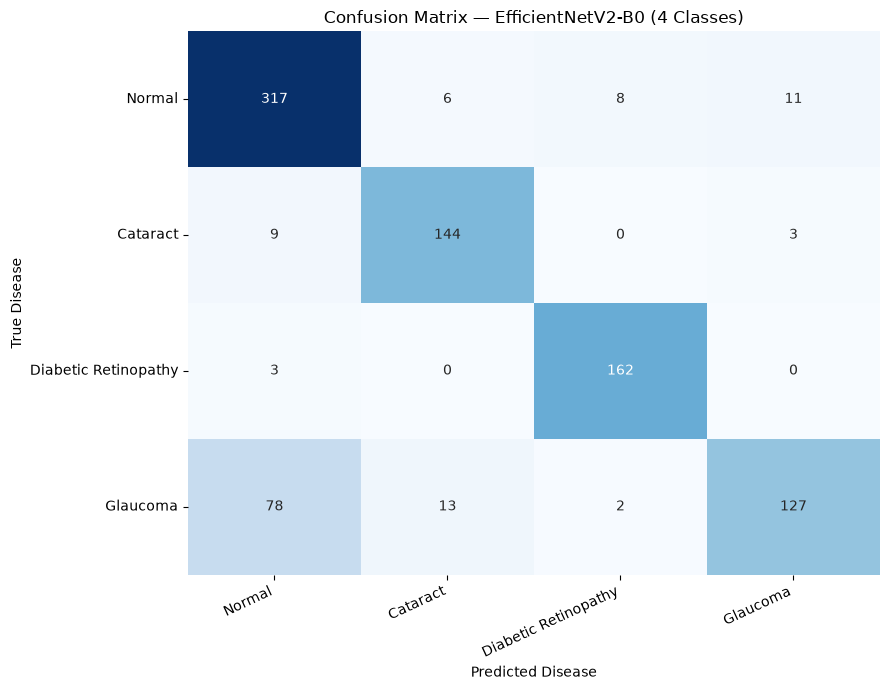

In [22]:
# Step 6 — Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=CLASS_IDS)

cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
print("Confusion matrix:")
display(cm_df)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix — EfficientNetV2-B0 (4 Classes)")
plt.xlabel("Predicted Disease")
plt.ylabel("True Disease")
plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

cm_df.to_csv(OUTPUT_DIR / "confusion_matrix.csv")


In [23]:
# Step 7 — Class-wise error analysis
analysis_df = test_df.copy()
analysis_df["true_disease"] = analysis_df["class_id"].map(dict(enumerate(CLASS_NAMES)))
analysis_df["predicted_class_id"] = y_pred
analysis_df["predicted_disease"] = [CLASS_NAMES[i] for i in y_pred]
analysis_df["confidence"] = confidence
analysis_df["correct"] = analysis_df["class_id"] == y_pred

for i, name in enumerate(CLASS_NAMES):
    analysis_df[f"prob_{name.lower().replace(' ', '_')}"] = all_probs[:, i]

analysis_df["error_type"] = np.where(
    analysis_df["correct"], "Correct", 
    analysis_df["true_disease"] + " -> " + analysis_df["predicted_disease"]
)

errors_df = analysis_df[~analysis_df["correct"]].copy()

print("Total errors:", len(errors_df))
print("\nMost frequent misclassification pairs:")
pair_counts = (
    errors_df.groupby(["true_disease", "predicted_disease"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
display(pair_counts)

pair_counts.to_csv(OUTPUT_DIR / "misclassification_pairs.csv", index=False)
analysis_df.to_csv(OUTPUT_DIR / "all_test_predictions.csv", index=False)
errors_df.to_csv(OUTPUT_DIR / "all_errors.csv", index=False)


Total errors: 133

Most frequent misclassification pairs:


,true_disease,predicted_disease,count
5,Glaucoma,Normal,78
3,Glaucoma,Cataract,13
8,Normal,Glaucoma,11
1,Cataract,Normal,9
7,Normal,Diabetic Retinopathy,8
6,Normal,Cataract,6
0,Cataract,Glaucoma,3
2,Diabetic Retinopathy,Normal,3
4,Glaucoma,Diabetic Retinopathy,2


Class-wise performance and errors:


,disease,precision,recall,f1_score,support,errors,error_rate
0,Normal,0.7789,0.9269,0.8465,342,25,0.0731
1,Cataract,0.8834,0.9231,0.9028,156,12,0.0769
2,Diabetic Retinopathy,0.9419,0.9818,0.9614,165,3,0.0182
3,Glaucoma,0.9007,0.5773,0.7036,220,93,0.4227


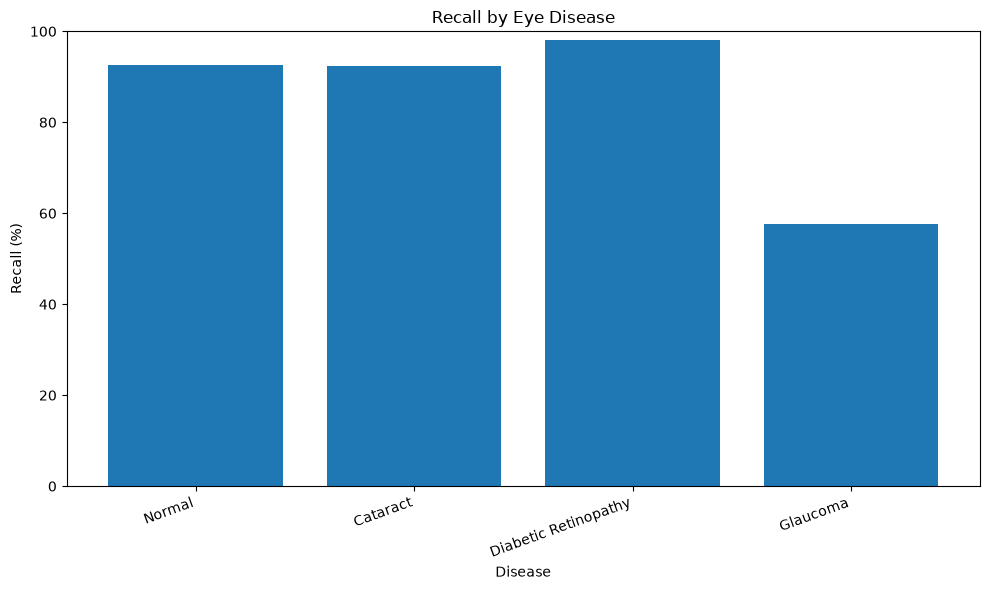

In [24]:
# Step 8 — Per-class error counts and recall
class_summary = metrics_df.copy()
class_summary["errors"] = class_summary["support"] - (
    [cm[i, i] for i in CLASS_IDS]
)
class_summary["error_rate"] = class_summary["errors"] / class_summary["support"]

print("Class-wise performance and errors:")
display(class_summary.round(4))

class_summary.to_csv(OUTPUT_DIR / "classwise_error_summary.csv", index=False)

plt.figure(figsize=(10, 6))
plt.bar(CLASS_NAMES, class_summary["recall"] * 100)
plt.ylabel("Recall (%)")
plt.xlabel("Disease")
plt.title("Recall by Eye Disease")
plt.ylim(0, 100)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "recall_by_class.png", dpi=300, bbox_inches="tight")
plt.show()


Confidence summary:
mean_confidence: 0.8851
median_confidence: 0.9443
min_confidence: 0.3767
max_confidence: 1.0000
mean_correct_confidence: 0.9075
mean_incorrect_confidence: 0.7589


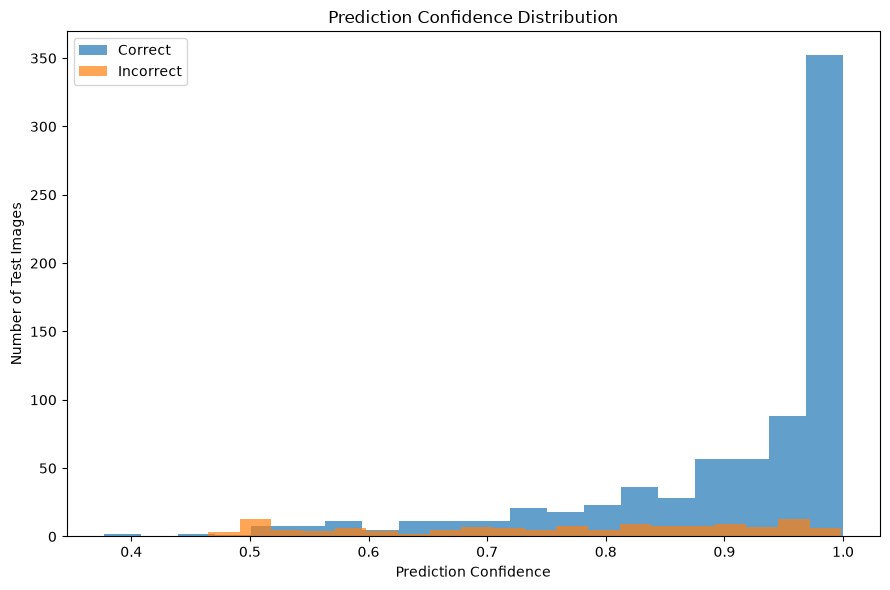

In [25]:
# Step 9 — Confidence analysis
confidence_summary = {
    "mean_confidence": float(np.mean(confidence)),
    "median_confidence": float(np.median(confidence)),
    "min_confidence": float(np.min(confidence)),
    "max_confidence": float(np.max(confidence)),
    "mean_correct_confidence": float(np.mean(confidence[y_true == y_pred])),
    "mean_incorrect_confidence": float(np.mean(confidence[y_true != y_pred])) if incorrect else None,
}

print("Confidence summary:")
for k, v in confidence_summary.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

plt.figure(figsize=(9, 6))
plt.hist(confidence[y_true == y_pred], bins=20, alpha=0.7, label="Correct")
if incorrect:
    plt.hist(confidence[y_true != y_pred], bins=20, alpha=0.7, label="Incorrect")
plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Test Images")
plt.title("Prediction Confidence Distribution")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confidence_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

with open(OUTPUT_DIR / "confidence_summary.json", "w", encoding="utf-8") as f:
    json.dump(confidence_summary, f, indent=2)


In [26]:
# Step 10 — High-confidence wrong predictions
wrong_df = analysis_df[~analysis_df["correct"]].copy()
high_conf_wrong = wrong_df.sort_values("confidence", ascending=False).head(30)

print("Top high-confidence incorrect predictions:")
display(
    high_conf_wrong[
        ["image_path", "true_disease", "predicted_disease", "confidence"]
    ].round(4)
)

high_conf_wrong.to_csv(
    OUTPUT_DIR / "high_confidence_wrong_predictions.csv", index=False
)


Top high-confidence incorrect predictions:


,image_path,true_disease,predicted_disease,confidence
31,d:\Practice Projects\Disease Detection\dataset...,Glaucoma,Cataract,0.9986
360,d:\Practice Projects\Disease Detection\dataset...,Normal,Diabetic Retinopathy,0.9982
582,d:\Practice Projects\Disease Detection\dataset...,Glaucoma,Cataract,0.9960
714,d:\Practice Projects\Disease Detection\dataset...,Glaucoma,Cataract,0.9900
490,d:\Practice Projects\Disease Detection\dataset...,Glaucoma,Cataract,0.9799
834,d:\Practice Projects\Disease Detection\dataset...,Glaucoma,Normal,0.9728
807,d:\Practice Projects\Disease Detection\dataset...,Glaucoma,Diabetic Retinopathy,0.9704
427,d:\Practice Projects\Disease Detection\dataset...,Glaucoma,Cataract,0.9688
602,d:\Practice Projects\Disease Detection\dataset...,Glaucoma,Normal,0.9688
382,d:\Practice Projects\Disease Detection\dataset...,Glaucoma,Normal,0.9663


In [27]:
# Step 11 — Low-confidence predictions
low_conf = analysis_df.sort_values("confidence", ascending=True).head(30)

print("Lowest-confidence predictions:")
display(
    low_conf[
        ["image_path", "true_disease", "predicted_disease", "confidence"]
    ].round(4)
)

low_conf.to_csv(OUTPUT_DIR / "low_confidence_predictions.csv", index=False)


Lowest-confidence predictions:


,image_path,true_disease,predicted_disease,confidence
250,d:\Practice Projects\Disease Detection\dataset...,Normal,Normal,0.3767
302,d:\Practice Projects\Disease Detection\dataset...,Glaucoma,Glaucoma,0.3832
587,d:\Practice Projects\Disease Detection\dataset...,Cataract,Cataract,0.4448
274,d:\Practice Projects\Disease Detection\dataset...,Glaucoma,Glaucoma,0.4466
138,d:\Practice Projects\Disease Detection\dataset...,Normal,Cataract,0.4648
854,d:\Practice Projects\Disease Detection\dataset...,Normal,Normal,0.4704
269,d:\Practice Projects\Disease Detection\dataset...,Glaucoma,Normal,0.4799
255,d:\Practice Projects\Disease Detection\dataset...,Glaucoma,Cataract,0.4832
4,d:\Practice Projects\Disease Detection\dataset...,Glaucoma,Normal,0.4985
546,d:\Practice Projects\Disease Detection\dataset...,Glaucoma,Normal,0.4992


Glaucoma test images: 220
Correct Glaucoma: 127
Glaucoma recall: 57.73%

Glaucoma prediction distribution:
predicted_disease
Normal                   78
Cataract                 13
Diabetic Retinopathy      2
Glaucoma                127
Name: count, dtype: int64


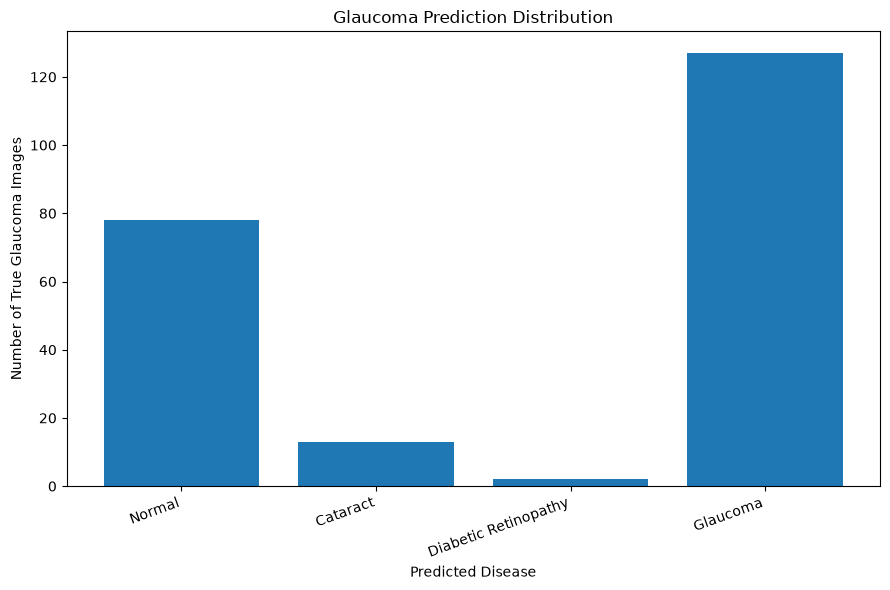

In [28]:
# Step 12 — Glaucoma-specific error analysis
glaucoma_true = analysis_df[analysis_df["true_disease"] == "Glaucoma"].copy()
glaucoma_correct = glaucoma_true["correct"].sum()
glaucoma_recall = glaucoma_correct / len(glaucoma_true) if len(glaucoma_true) else 0

glaucoma_prediction_distribution = (
    glaucoma_true["predicted_disease"].value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
)

print("Glaucoma test images:", len(glaucoma_true))
print("Correct Glaucoma:", int(glaucoma_correct))
print(f"Glaucoma recall: {glaucoma_recall*100:.2f}%")
print("\nGlaucoma prediction distribution:")
print(glaucoma_prediction_distribution)

glaucoma_errors = glaucoma_true[~glaucoma_true["correct"]].copy()
glaucoma_errors.to_csv(OUTPUT_DIR / "glaucoma_errors.csv", index=False)

pd.DataFrame({
    "predicted_disease": CLASS_NAMES,
    "count": [int(glaucoma_prediction_distribution[x]) for x in CLASS_NAMES]
}).to_csv(OUTPUT_DIR / "glaucoma_prediction_distribution.csv", index=False)

plt.figure(figsize=(9, 6))
plt.bar(CLASS_NAMES, [glaucoma_prediction_distribution[x] for x in CLASS_NAMES])
plt.ylabel("Number of True Glaucoma Images")
plt.xlabel("Predicted Disease")
plt.title("Glaucoma Prediction Distribution")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "glaucoma_prediction_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


In [29]:
# FINAL VALIDATION CELL
# Verifies that 08 now reproduces the validated pipeline result from 06/07.
# ROOT CAUSE FIX: Replaced tf.keras.utils.load_img (LANCZOS resampling) with
# PIL bilinear resize to match 06_model_training_v2 and 07_gradcam_v2.
VALIDATED_CORRECT   = 750   # from 06 and 07
VALIDATED_INCORRECT = 133

glaucoma_true_final = analysis_df[analysis_df['true_disease'] == 'Glaucoma']
glaucoma_recall_final = float(glaucoma_true_final['correct'].sum()) / len(glaucoma_true_final) * 100

status = 'PASS' if (correct == VALIDATED_CORRECT and incorrect == VALIDATED_INCORRECT) else 'FAIL'

print('=' * 60)
print('MODEL CONSISTENCY CHECK')
print('=' * 60)
print(f'Model file        : {MODEL_PATH.name}')
print(f'Test CSV          : {TEST_CSV.name}')
print(f'Test images       : {len(y_true)}')
print(f'Prediction pipeline: PIL bilinear resize (matches 06/07)')
print(f'Accuracy          : {accuracy*100:.2f}%')
print(f'Correct           : {correct}')
print(f'Incorrect         : {incorrect}')
print(f'Glaucoma recall   : {glaucoma_recall_final:.2f}%')
print(f'Consistency status: {status}')
print('=' * 60)

if status == 'FAIL':
    print(f'WARNING: Expected correct={VALIDATED_CORRECT}, incorrect={VALIDATED_INCORRECT}')
    print(f'         Got     correct={correct}, incorrect={incorrect}')


MODEL CONSISTENCY CHECK
Model file        : efficientnetv2_b0_4class_best.keras
Test CSV          : test.csv
Test images       : 883
Prediction pipeline: PIL bilinear resize (matches 06/07)
Accuracy          : 84.94%
Correct           : 750
Incorrect         : 133
Glaucoma recall   : 57.73%
Consistency status: PASS


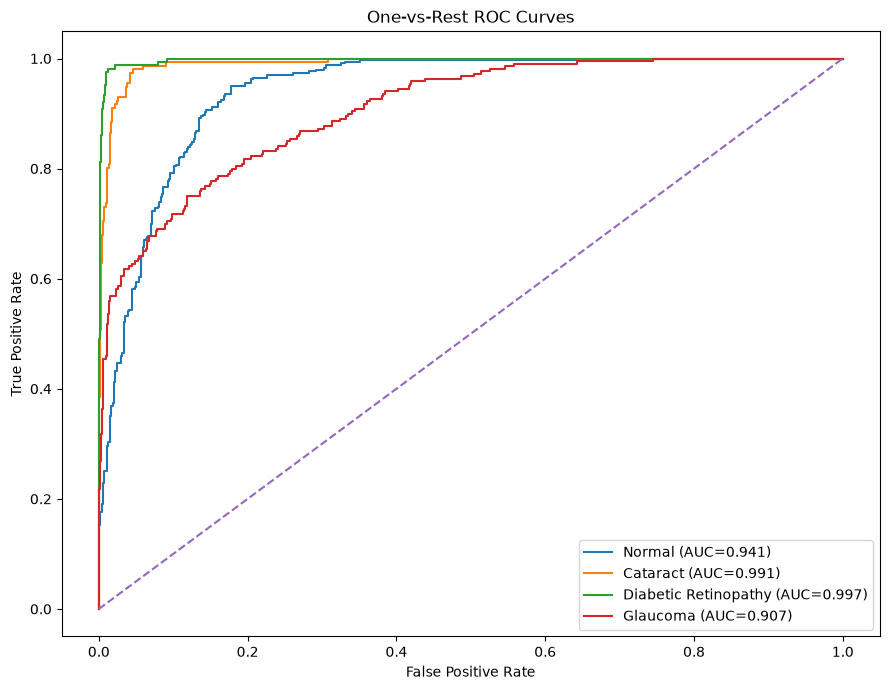

,disease,roc_auc
0,Normal,0.9408
1,Cataract,0.9910
2,Diabetic Retinopathy,0.9974
3,Glaucoma,0.9071


Macro ROC-AUC: 0.9591


In [30]:
# Step 13 — One-vs-rest ROC-AUC
# ROC-AUC is computed from the model probabilities, not hard predictions.
y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=len(CLASS_NAMES))

auc_rows = []
plt.figure(figsize=(9, 7))

for i, name in enumerate(CLASS_NAMES):
    try:
        fpr, tpr, _ = roc_curve(y_true_onehot[:, i], all_probs[:, i])
        class_auc = auc(fpr, tpr)
        auc_rows.append({"disease": name, "roc_auc": class_auc})
        plt.plot(fpr, tpr, label=f"{name} (AUC={class_auc:.3f})")
    except ValueError:
        auc_rows.append({"disease": name, "roc_auc": np.nan})

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC Curves")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()

auc_df = pd.DataFrame(auc_rows)
display(auc_df.round(4))
auc_df.to_csv(OUTPUT_DIR / "roc_auc_by_class.csv", index=False)

try:
    macro_auc = roc_auc_score(
        y_true_onehot, all_probs, multi_class="ovr", average="macro"
    )
    print(f"Macro ROC-AUC: {macro_auc:.4f}")
except ValueError:
    macro_auc = None
    print("Macro ROC-AUC could not be computed.")


Mean predicted probabilities by true disease:


,prob_normal,prob_cataract,prob_diabetic_retinopathy,prob_glaucoma
true_disease,,,,
Normal,0.8174,0.0197,0.0341,0.1288
Cataract,0.0549,0.9004,0.0056,0.0391
Diabetic Retinopathy,0.0377,0.0011,0.9555,0.0058
Glaucoma,0.3165,0.0713,0.0316,0.5806


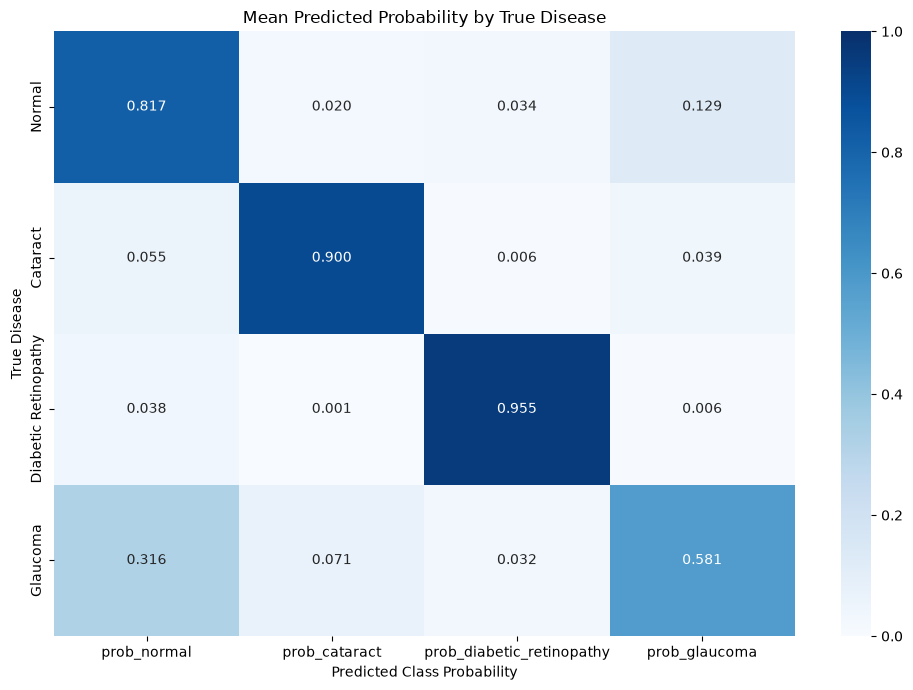

In [31]:
# Step 14 — Probability statistics by true disease
prob_columns = [
    "prob_normal",
    "prob_cataract",
    "prob_diabetic_retinopathy",
    "prob_glaucoma",
]

prob_stats = (
    analysis_df.groupby("true_disease")[prob_columns]
    .mean()
    .reindex(CLASS_NAMES)
)

print("Mean predicted probabilities by true disease:")
display(prob_stats.round(4))
prob_stats.to_csv(OUTPUT_DIR / "mean_probabilities_by_true_disease.csv")

plt.figure(figsize=(10, 7))
sns.heatmap(prob_stats, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1)
plt.title("Mean Predicted Probability by True Disease")
plt.xlabel("Predicted Class Probability")
plt.ylabel("True Disease")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "mean_probability_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


In [32]:
# Step 15 — Compare against the verified Grad-CAM V2 analysis
# This cell does not recompute Grad-CAM. It checks whether the existing Grad-CAM
# outputs are available and summarizes them for the final analysis.

if GRADCAM_CSV.exists():
    gradcam_df = pd.read_csv(GRADCAM_CSV)
    print("Grad-CAM results found:", len(gradcam_df))
    display(gradcam_df.head())
else:
    gradcam_df = None
    print("Grad-CAM results CSV not found:", GRADCAM_CSV)

if GLAUCOMA_CSV.exists():
    glaucoma_gradcam_df = pd.read_csv(GLAUCOMA_CSV)
    print("\nGlaucoma Grad-CAM analysis found:", len(glaucoma_gradcam_df))
    display(glaucoma_gradcam_df.head())
else:
    glaucoma_gradcam_df = None
    print("Glaucoma Grad-CAM analysis CSV not found:", GLAUCOMA_CSV)


Grad-CAM results found: 18


,image_path,true_class_id,true_disease,predicted_class_id,predicted_disease,confidence,correct_prediction,gradcam_target_layer,heatmap_shape,heatmap_min,heatmap_max,output_path,category
0,d:\Practice Projects\Disease Detection\dataset...,0,Normal,0,Normal,0.996517,True,top_activation,"(7, 7)",0.000000,1.0,d:\Practice Projects\Disease Detection\reports...,correct_predictions
1,d:\Practice Projects\Disease Detection\dataset...,0,Normal,0,Normal,0.995880,True,top_activation,"(7, 7)",0.000000,1.0,d:\Practice Projects\Disease Detection\reports...,correct_predictions
2,d:\Practice Projects\Disease Detection\dataset...,1,Cataract,1,Cataract,0.999991,True,top_activation,"(7, 7)",0.121053,1.0,d:\Practice Projects\Disease Detection\reports...,correct_predictions
3,d:\Practice Projects\Disease Detection\dataset...,1,Cataract,1,Cataract,0.999985,True,top_activation,"(7, 7)",0.083787,1.0,d:\Practice Projects\Disease Detection\reports...,correct_predictions
4,d:\Practice Projects\Disease Detection\dataset...,2,Diabetic Retinopathy,2,Diabetic Retinopathy,0.999999,True,top_activation,"(7, 7)",0.000000,1.0,d:\Practice Projects\Disease Detection\reports...,correct_predictions



Glaucoma Grad-CAM analysis found: 220


,image_path,true_class_id,true_disease,predicted_class_id,predicted_disease,confidence,correct_prediction,prob_normal,prob_cataract,prob_diabetic_retinopathy,prob_glaucoma,is_glaucoma_correct,error_type
0,d:\Practice Projects\Disease Detection\dataset...,3,Glaucoma,1,Cataract,0.565276,False,0.030946,0.565276,0.000003,0.403776,False,Glaucoma misclassified as Cataract
1,d:\Practice Projects\Disease Detection\dataset...,3,Glaucoma,0,Normal,0.498495,False,0.498495,0.137716,0.157592,0.206197,False,Glaucoma misclassified as Normal
2,d:\Practice Projects\Disease Detection\dataset...,3,Glaucoma,3,Glaucoma,0.949130,True,0.050218,0.000543,0.000109,0.949130,True,Correct Glaucoma
3,d:\Practice Projects\Disease Detection\dataset...,3,Glaucoma,3,Glaucoma,0.525915,True,0.473324,0.000733,0.000028,0.525915,True,Correct Glaucoma
4,d:\Practice Projects\Disease Detection\dataset...,3,Glaucoma,3,Glaucoma,0.808147,True,0.188565,0.001061,0.002227,0.808147,True,Correct Glaucoma


In [33]:
# Step 16 — Automatically generate a final analysis summary
best_class = metrics_df.loc[metrics_df["f1_score"].idxmax(), "disease"]
weakest_class = metrics_df.loc[metrics_df["recall"].idxmin(), "disease"]
most_common_error = (
    f"{pair_counts.iloc[0]['true_disease']} -> {pair_counts.iloc[0]['predicted_disease']}"
    if len(pair_counts) else "None"
)

summary = {
    "model": MODEL_PATH.name,
    "test_split": str(TEST_CSV),
    "classes": CLASS_NAMES,
    "test_images": int(len(y_true)),
    "correct_predictions": correct,
    "incorrect_predictions": incorrect,
    "accuracy_percent": round(float(accuracy * 100), 2),
    "best_f1_class": str(best_class),
    "weakest_recall_class": str(weakest_class),
    "glaucoma_recall_percent": round(float(glaucoma_recall * 100), 2),
    "most_common_misclassification": most_common_error,
    "macro_roc_auc": None if macro_auc is None else round(float(macro_auc), 4),
}

with open(OUTPUT_DIR / "final_analysis_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("=" * 60)
print("FINAL MODEL ANALYSIS — V2")
print("=" * 60)
print(f"Model                 : {MODEL_PATH.name}")
print(f"Test images           : {len(y_true)}")
print(f"Correct predictions   : {correct}")
print(f"Incorrect predictions : {incorrect}")
print(f"Test accuracy         : {accuracy*100:.2f}%")
print(f"Best F1 class         : {best_class}")
print(f"Weakest recall class  : {weakest_class}")
print(f"Glaucoma recall       : {glaucoma_recall*100:.2f}%")
print(f"Most common error     : {most_common_error}")
print(f"Macro ROC-AUC         : {macro_auc:.4f}" if macro_auc is not None else "Macro ROC-AUC         : N/A")
print("=" * 60)
print("\nAll analysis files saved to:")
print(OUTPUT_DIR)


FINAL MODEL ANALYSIS — V2
Model                 : efficientnetv2_b0_4class_best.keras
Test images           : 883
Correct predictions   : 750
Incorrect predictions : 133
Test accuracy         : 84.94%
Best F1 class         : Diabetic Retinopathy
Weakest recall class  : Glaucoma
Glaucoma recall       : 57.73%
Most common error     : Glaucoma -> Normal
Macro ROC-AUC         : 0.9591

All analysis files saved to:
d:\Practice Projects\Disease Detection\reports\model_analysis_v2


## Final interpretation

Use the generated metrics and plots in the research paper rather than hard-coding values from an older experiment.

The current V2 pipeline's verified test result is **84.94% accuracy on 883 untouched test images (750 correct, 133 incorrect)**. The Grad-CAM V2 analysis also reported **57.73% glaucoma recall**, so glaucoma is the main class-specific weakness to discuss honestly in the limitations/error-analysis section.

This notebook is an analysis notebook only. It does **not** retrain or modify the final model.
